# Introduction

I want to use `osmnx` to get the

1. Roads
2. Pedestrian
3. Cycling Paths

For Singapore (Woodlands and Sembawang $\approx\text{29 km}^2$) and the city of Delft  ($26 \text{km}^2$)



network_type (str) – {“all”, “all_public”, “bike”, “drive”, “drive_service”, “walk”} What type of street network to retrieve if custom_filter is None.

In [37]:
# Imports
import networkx as nx
import osmnx as ox
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

# Singapore (Woodlands + Sembawang)

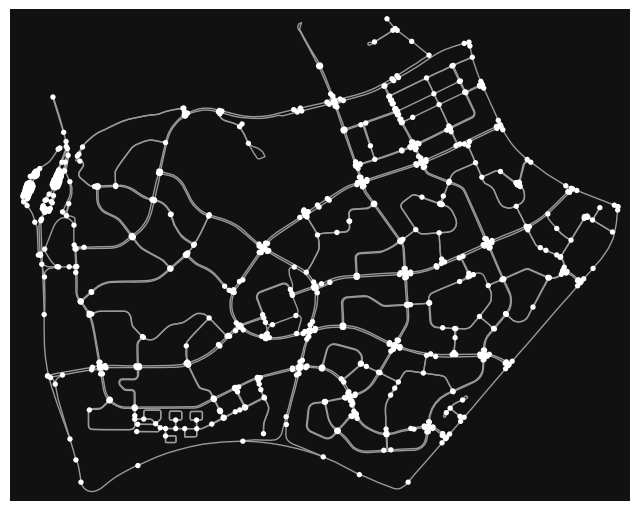

In [2]:
# download/model a street network for some city then visualize it
G_sg_woodlands_roads = ox.graph.graph_from_place("Woodlands, Singapore", network_type="drive")
fig, ax = ox.plot.plot_graph(G_sg_woodlands_roads)

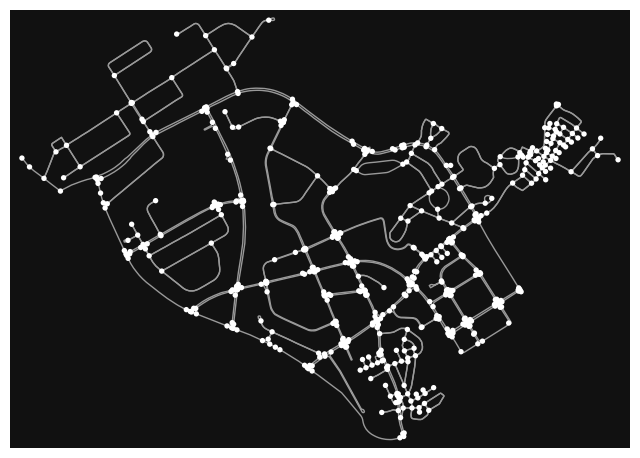

In [10]:
# download/model a street network for some city then visualize it
G_sg_sembawang_roads = ox.graph.graph_from_place("Sembawang, Singapore", network_type="drive")
fig, ax = ox.plot.plot_graph(G_sg_sembawang_roads)

I need to combine Woodlands and Sembawang as one polygon (coordintes 
in unprojected latitude-longitude degrees (EPSG: 4236))
Then do a 

```python
osmnx.graph.graph_from_polygon(polygon, *, network_type='all', simplify=True, retain_all=False, truncate_by_edge=False, custom_filter=None)
```

# Get Woodlands-Sembawang Bounding Polygon

In [15]:
# Read subzone geojson
sg_subzone_gdf = gpd.read_file("./data/raw/MasterPlan2019SubzoneBoundaryNoSeaGEOJSON.geojson")
sg_subzone_gdf.head(2)

,OBJECTID,SUBZONE_NO,SUBZONE_N,SUBZONE_C,CA_IND,PLN_AREA_N,PLN_AREA_C,REGION_N,REGION_C,INC_CRC,FMEL_UPD_D,SHAPE.AREA,SHAPE.LEN,geometry
0,676,12,DEPOT ROAD,BMSZ12,N,BUKIT MERAH,BM,CENTRAL REGION,CR,C22DED671DE2A940,20191223152313,442297.509556,4281.667289,"POLYGON ((103.81454 1.28239, 103.81427 1.28253..."
1,677,2,BUKIT MERAH,BMSZ02,N,BUKIT MERAH,BM,CENTRAL REGION,CR,085EF219A5A1AEAD,20191223152313,411722.830243,3074.963234,"POLYGON ((103.82209 1.28049, 103.82209 1.28057..."


In [21]:
# 
planning_areas_to_keep = ['WOODLANDS', 'SEMBAWANG']
wlds_semb_plan_areas = sg_subzone_gdf[sg_subzone_gdf['PLN_AREA_N'].isin(planning_areas_to_keep)]
wlds_semb_plan_areas = wlds_semb_plan_areas.dissolve(by="PLN_AREA_N")
wlds_semb_plan_areas.head(2)
# sg_subzone_gdf['PLN_AREA_N'].unique()

,geometry,OBJECTID,SUBZONE_NO,SUBZONE_N,SUBZONE_C,CA_IND,PLN_AREA_C,REGION_N,REGION_C,INC_CRC,FMEL_UPD_D,SHAPE.AREA,SHAPE.LEN
PLN_AREA_N,,,,,,,,,,,,,
SEMBAWANG,"POLYGON ((103.83039 1.44169, 103.83031 1.44163...",938,3,SEMBAWANG CENTRAL,SBSZ03,N,SB,NORTH REGION,NR,5FDC3CA8CAC33369,20191223152313,9.614217e+05,3950.533597
WOODLANDS,"POLYGON ((103.78253 1.42655, 103.78205 1.42654...",937,3,WOODLANDS EAST,WDSZ03,N,WD,NORTH REGION,NR,C90769E43EE6B0F2,20191223152313,2.553464e+06,6603.608301


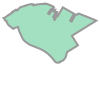

In [23]:
wlds_semb_plan_areas.iloc[0].geometry

<Axes: >

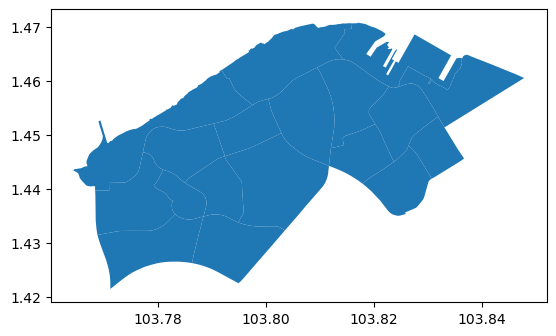

In [19]:
wlds_semb_plan_areas.plot()

In [ ]:
# Reproject to SVY21
wlds_semb_plan_areas

,geometry,OBJECTID,SUBZONE_NO,SUBZONE_N,SUBZONE_C,CA_IND,PLN_AREA_C,REGION_N,REGION_C,INC_CRC,FMEL_UPD_D,SHAPE.AREA,SHAPE.LEN
PLN_AREA_N,,,,,,,,,,,,,
SEMBAWANG,"POLYGON ((103.83039 1.44169, 103.83031 1.44163...",938,3,SEMBAWANG CENTRAL,SBSZ03,N,SB,NORTH REGION,NR,5FDC3CA8CAC33369,20191223152313,9.614217e+05,3950.533597
WOODLANDS,"POLYGON ((103.78253 1.42655, 103.78205 1.42654...",937,3,WOODLANDS EAST,WDSZ03,N,WD,NORTH REGION,NR,C90769E43EE6B0F2,20191223152313,2.553464e+06,6603.608301


In [38]:
wlds_semb_plan_areas_svy21 = wlds_semb_plan_areas.to_crs(epsg=3414)

In [40]:
# Original projection is 4326
wlds_semb_sizes_df = pd.DataFrame(wlds_semb_plan_areas_svy21.area).reset_index().rename(
    columns={'PLN_AREA_N':'planning_area_name',
             0: 'area'})

# Convert area from metres to km^2
wlds_semb_sizes_df['area'] = wlds_semb_sizes_df['area'].apply(lambda area: area/10**6)

print(f"Total size of Sembawang and Woodlands is {sum(wlds_semb_sizes_df['area'])} km^2.")

Total size of Sembawang and Woodlands is 26.248709284372953 km^2.


# Netherlands (Delft)